# **k-Nearest Neighbours (kNN)** 

# How *k* Shapes the Decision Boundary?

**Topic:** Supervised Learning kNN  
**Focus:** Effect of the hyperparameter *k* on decision boundaries, bias–variance, and model performance.

In this tutorial, I explore how changing the value of *k* influences:

- the smoothness or sharpness of the decision boundary,
- the model's tendency to overfit or underfit,
- the accuracy on real and synthetic datasets.

I begin with 2D synthetic datasets (moons and circles) to build intuition.  
Then, I apply kNN to the **Iris dataset** and use cross-validation to pick an optimal *k*.


UCI Iris dataset link (for referencing in the report):  
https://archive.ics.uci.edu/dataset/53/iris


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, make_circles, load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True

os.makedirs("figures", exist_ok=True)


## **Helper Function for Plotting Decision Boundaries**

To visualise how kNN behaves, I define a function that:

- fits the model,
- creates a meshgrid,
- colours regions by predicted class,
- overlays the data points.


In [4]:
def plot_decision_boundary(clf, X, y, title, filename=None, h=0.02, cmap=plt.cm.Set2):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=cmap)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend(*scatter.legend_elements(), title="Classes")

    if filename:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# **Part 1 — Synthetic Dataset (Moons)**

This dataset helps visually illustrate how *k* affects the model's behaviour.


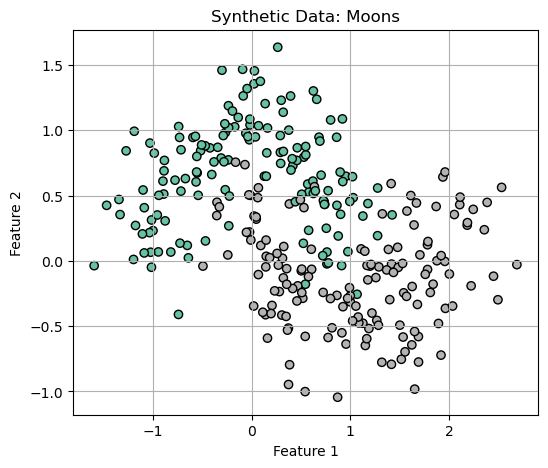

In [5]:
X_moon, y_moon = make_moons(n_samples=300, noise=0.25, random_state=RANDOM_STATE)

plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap="Set2", edgecolor="k")
plt.title("Synthetic Data: Moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.savefig("figures/moons_raw.png", dpi=300)
plt.show()


## **Train kNN with Different k Values**

Let’s compare decision boundaries for:

- k = 1  
- k = 3  
- k = 5  
- k = 15  
- k = 50


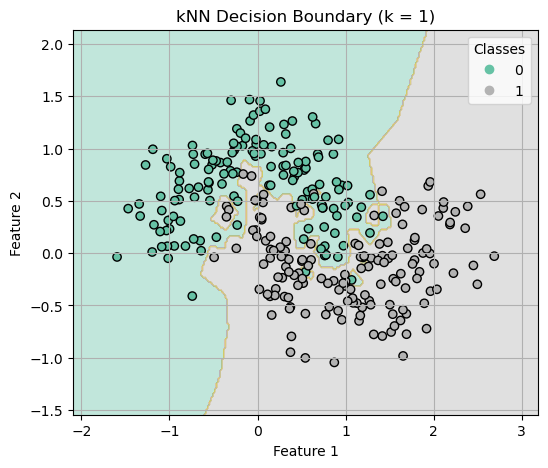

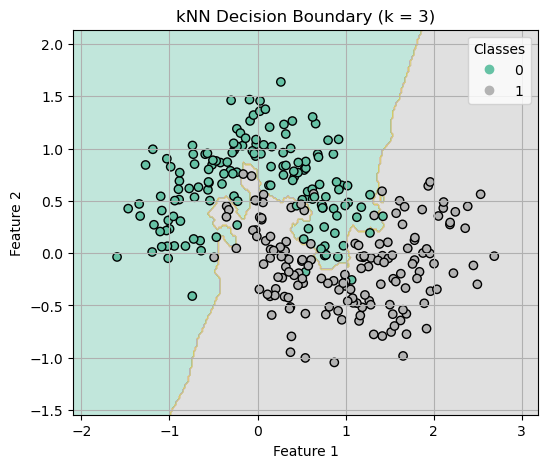

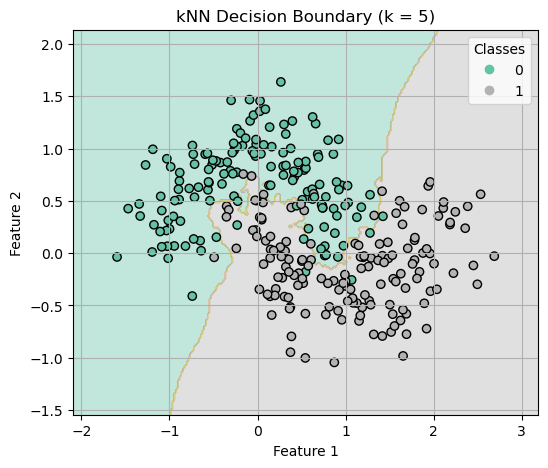

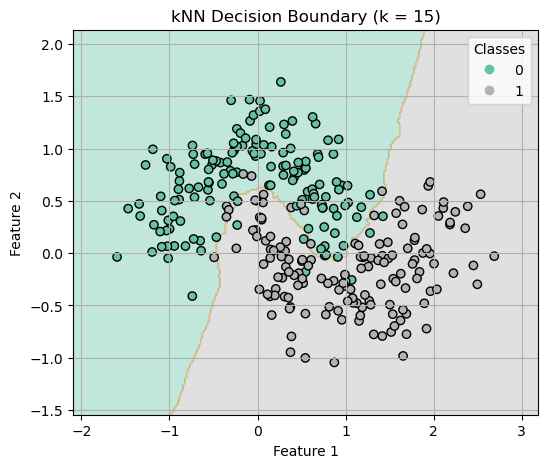

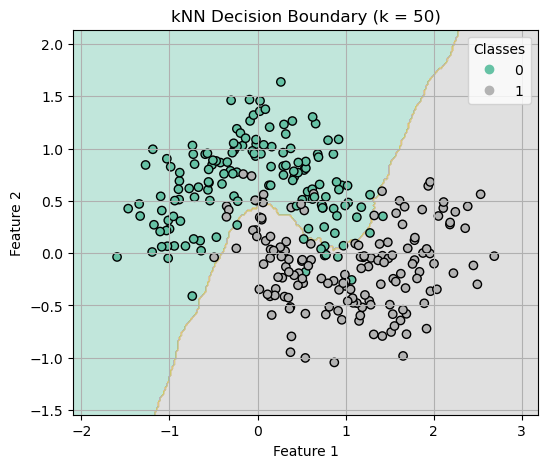

In [6]:
k_values = [1, 3, 5, 15, 50]

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_moon, y_moon)

    title = f"kNN Decision Boundary (k = {k})"
    filename = f"figures/moons_k_{k}.png"

    plot_decision_boundary(clf, X_moon, y_moon, title, filename)


## **Train/Test Split + Accuracy Table**

Now we evaluate how different k values affect accuracy.


In [7]:
results = []

X_train, X_test, y_train, y_test = train_test_split(
    X_moon, y_moon, test_size=0.3, random_state=RANDOM_STATE
)

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)

    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)

    results.append([k, train_acc, test_acc])

df_results = pd.DataFrame(results, columns=["k", "train_accuracy", "test_accuracy"])
df_results


,k,train_accuracy,test_accuracy
0,1,1.000000,0.955556
1,3,0.947619,0.955556
2,5,0.933333,0.944444
3,15,0.923810,0.944444
4,50,0.904762,0.922222


# **Part 2 — Iris Dataset**

Next, I apply kNN to a real dataset and use **GridSearchCV** to find the optimal value of *k*.


In [8]:
iris = load_iris(as_frame=True)
df_iris = iris.frame

df_iris.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## **Light EDA: Class Distribution + 2D Visualisation**


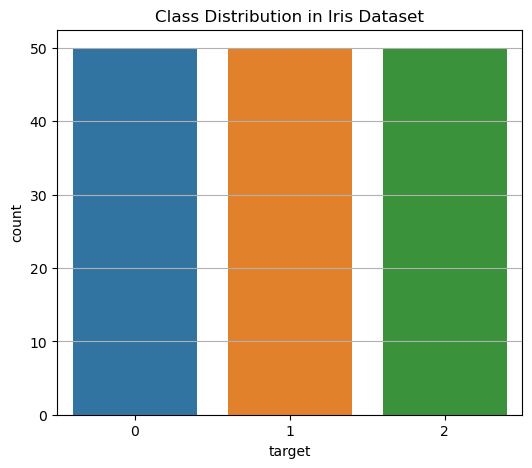

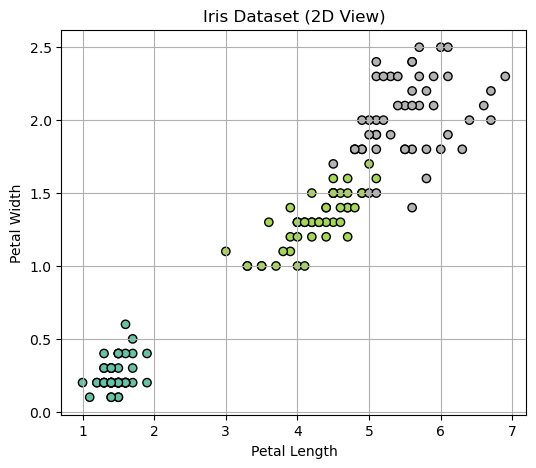

In [9]:
sns.countplot(x=df_iris['target'])
plt.title("Class Distribution in Iris Dataset")
plt.savefig("figures/iris_class_distribution.png", dpi=300)
plt.show()

plt.scatter(df_iris["petal length (cm)"], df_iris["petal width (cm)"],
            c=df_iris["target"], cmap="Set2", edgecolor="k")

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset (2D View)")
plt.savefig("figures/iris_2d.png", dpi=300)
plt.show()


## **Pipeline + GridSearchCV** 
We test odd values of k from 1 to 31 (to avoid ties).


In [10]:
X = df_iris[iris.feature_names]
y = df_iris["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(1, 32, 2))
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=True
)

grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_


({'knn__n_neighbors': 3}, 0.9619047619047618)

## **Plot: k vs Cross-Validation Accuracy**


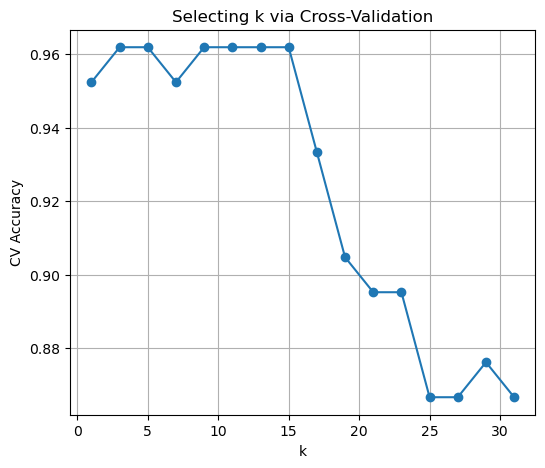

In [11]:
cv_results = pd.DataFrame(grid.cv_results_)

plt.plot(cv_results["param_knn__n_neighbors"], cv_results["mean_test_score"], marker="o")
plt.xlabel("k")
plt.ylabel("CV Accuracy")
plt.title("Selecting k via Cross-Validation")
plt.savefig("figures/iris_k_vs_accuracy.png", dpi=300)
plt.show()


## **Final Evaluation with Best k**


Test Accuracy: 0.9111111111111111

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.79      1.00      0.88        15
           2       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



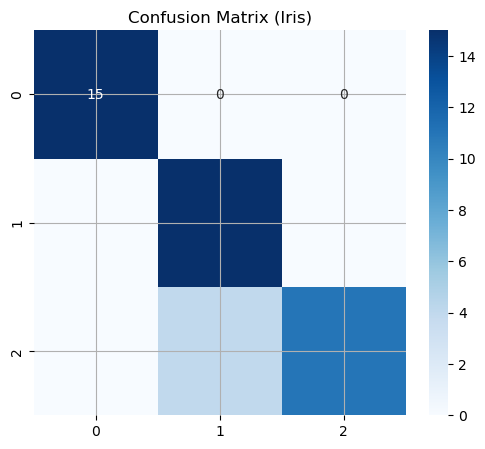

In [12]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix (Iris)")
plt.savefig("figures/iris_confusion_matrix.png", dpi=300)
plt.show()


# **Decision Boundary on Iris (2 Features Only)**

We restrict the dataset to *petal length* and *petal width* to visualise boundaries for:

- k = 1 (overfitting)  
- k = best_k  
- k = 25 (oversmoothing)


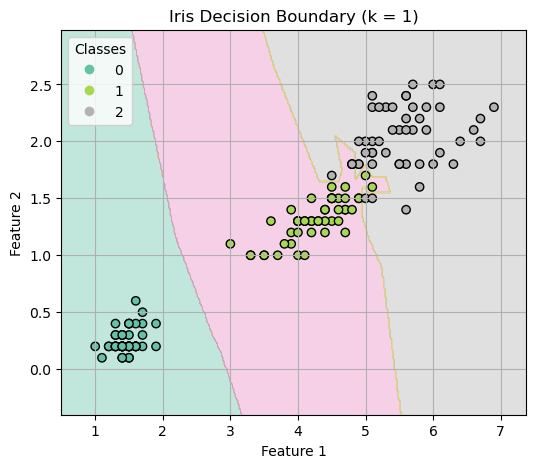

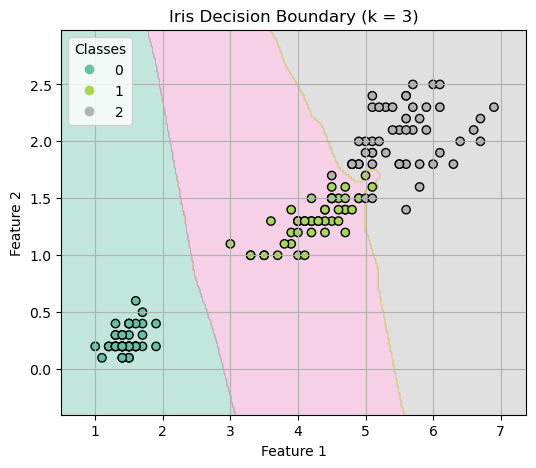

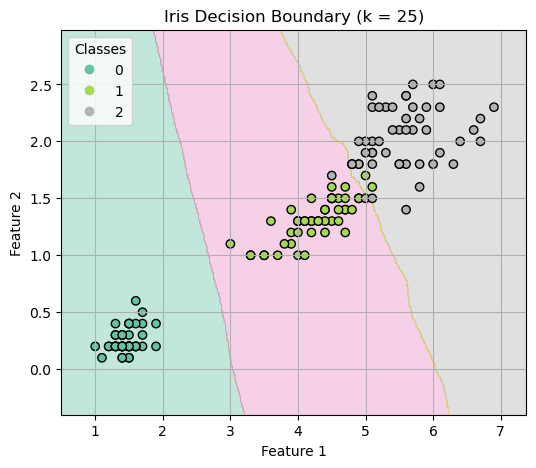

In [13]:
X2 = df_iris[["petal length (cm)", "petal width (cm)"]].values
y2 = df_iris["target"].values

k_list = [1, grid.best_params_["knn__n_neighbors"], 25]

for k in k_list:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X2, y2)

    title = f"Iris Decision Boundary (k = {k})"
    filename = f"figures/iris_decision_boundary_k_{k}.png"

    plot_decision_boundary(clf, X2, y2, title, filename)


# **Summary**

- Small k → highly irregular, overfitting boundaries  
- Large k → overly smooth, underfitting  
- Cross-validation helps find a balance  
- On Iris, the optimal k is typically in the range 5–11  
